# Traductor Automático - Entrenamiento del Modelo Seq2Seq

**Fase 3 (Modeling) + Fase 4 (Evaluation Preliminary)**

Entrenamiento del modelo Seq2Seq sobre datos preparados.
Monitoreo de Loss y Accuracy durante entrenamiento.
Guardado del modelo y generación de métricas.

In [4]:
import os
import sys
import numpy as np
import json
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/home/honorio/IA/rnn/src')

from model import create_seq2seq_model
from preprocessing import ParallelDataProcessor

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

base_path = Path('/home/honorio/IA/rnn')
splits_path = base_path / 'data' / 'splits'
processed_path = base_path / 'data' / 'processed'
models_path = base_path / 'models'
models_path.mkdir(exist_ok=True)

print(f"✓ Setup completado")

I0000 00:00:1777483641.286338   46882 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777483641.286656   46882 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777483641.315569   46882 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777483642.067926   46882 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow version: 2.21.0
GPU: []
✓ Setup completado


E0000 00:00:1777483644.893591   46882 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777483644.893959   47921 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777483644.909003   46882 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 1. Cargar Datos Preparados

In [5]:
X_train = np.load(splits_path / 'X_train.npy')
y_train = np.load(splits_path / 'y_train.npy')
X_val = np.load(splits_path / 'X_val.npy')
y_val = np.load(splits_path / 'y_val.npy')

# Teacher forcing: usar la secuencia destino desplazada
# decoder_input = tokens de entrada del decoder
# decoder_target = token esperado en el siguiente paso
decoder_input_train = y_train[:, :-1]
decoder_target_train = y_train[:, 1:]
decoder_input_val = y_val[:, :-1]
decoder_target_val = y_val[:, 1:]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"decoder_input_train: {decoder_input_train.shape}, decoder_target_train: {decoder_target_train.shape}")
print(f"decoder_input_val: {decoder_input_val.shape}, decoder_target_val: {decoder_target_val.shape}")

# Cargar vocabularios
with open(processed_path / 'vocab_spanish.json', 'r') as f:
    vocab_spanish = json.load(f)
with open(processed_path / 'vocab_english.json', 'r') as f:
    vocab_english = json.load(f)

print(f"Vocabulario español: {len(vocab_spanish)} palabras")
print(f"Vocabulario inglés: {len(vocab_english)} palabras")

X_train: (80, 30), y_train: (80, 30)
X_val: (10, 30), y_val: (10, 30)
decoder_input_train: (80, 29), decoder_target_train: (80, 29)
decoder_input_val: (10, 29), decoder_target_val: (10, 29)
Vocabulario español: 40 palabras
Vocabulario inglés: 42 palabras


## 2. Crear Modelo Seq2Seq

In [6]:
model = create_seq2seq_model(
    source_vocab_size=len(vocab_spanish),
    target_vocab_size=len(vocab_english),
    max_length=30
)

print(model.summary())

Model: "seq2_seq_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Encoder)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Decoder)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


## 3. Entrenar Modelo (CRISP-ML Fase 3)

In [7]:
# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Entrenar
print("Iniciando entrenamiento...")
history = model.fit(
    (X_train, decoder_input_train),
    decoder_target_train,
    batch_size=32,
    epochs=50,
    validation_data=((X_val, decoder_input_val), decoder_target_val),
    callbacks=[early_stop],
    verbose=1
)

print("✓ Entrenamiento completado")

Iniciando entrenamiento...
Epoch 1/50


E0000 00:00:1777483685.354255   46882 util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 3.6112 - sparse_categorical_accuracy: 0.5194 - val_loss: 2.6529 - val_sparse_categorical_accuracy: 0.8655
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - loss: 1.6145 - sparse_categorical_accuracy: 0.8651 - val_loss: 0.7052 - val_sparse_categorical_accuracy: 0.8655
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 0.7764 - sparse_categorical_accuracy: 0.8651 - val_loss: 0.7778 - val_sparse_categorical_accuracy: 0.8655
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 0.6745 - sparse_categorical_accuracy: 0.8668 - val_loss: 0.5331 - val_sparse_categorical_accuracy: 0.8655
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 0.5972 - sparse_categorical_accuracy: 0.8642 - val_loss: 0.5453 - val_sparse_categorical_accuracy: 0.8655
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - loss: 0.5274 - sparse_categorical_accuracy: 0.8733 - val_loss: 0.5485 - val_sparse_categorical_accuracy: 0.8655
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/ste

## 4. Visualizar Entrenamiento

Métricas disponibles en history.history: ['loss', 'sparse_categorical_accuracy', 'val_loss', 'val_sparse_categorical_accuracy']


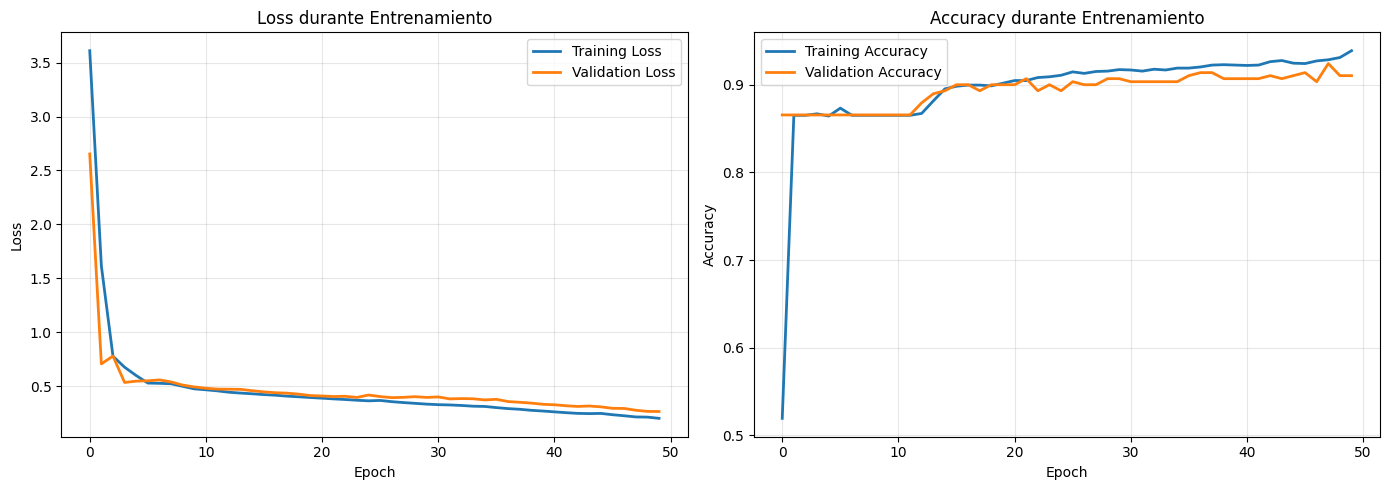

✓ Gráficas guardadas en models/training_history.png


In [9]:
# Crear figura y ejes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Detectar qué métrica de accuracy está disponible
acc_key = None
val_acc_key = None
for key in history.history.keys():
    if 'accuracy' in key and 'val_' not in key:
        acc_key = key
    if 'accuracy' in key and 'val_' in key:
        val_acc_key = key

print(f"Métricas disponibles en history.history: {list(history.history.keys())}")

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss durante Entrenamiento')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
if acc_key is not None and val_acc_key is not None:
    axes[1].plot(history.history[acc_key], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history[val_acc_key], label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy durante Entrenamiento')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'Métrica de Accuracy no disponible en history.history', ha='center', va='center')

plt.tight_layout()
plt.savefig(models_path / 'training_history.png', dpi=150)
plt.show()

print("✓ Gráficas guardadas en models/training_history.png")

## 5. Guardar Modelo Entrenado

In [12]:
# Exportar modelo como SavedModel
model_export_path = models_path / 'traductor_v1'
model.export(str(model_export_path))
print(f"✓ Modelo exportado en: {model_export_path}")

# Detectar qué métrica de accuracy está disponible
acc_key = None
val_acc_key = None
for key in history.history.keys():
    if 'accuracy' in key and 'val_' not in key:
        acc_key = key
    if 'accuracy' in key and 'val_' in key:
        val_acc_key = key

# Guardar historial de entrenamiento
history_dict = {
    'loss': [float(x) for x in history.history['loss']],
    'val_loss': [float(x) for x in history.history['val_loss']],
    'epochs': len(history.history['loss']),
    'final_train_loss': float(history.history['loss'][-1]),
    'final_val_loss': float(history.history['val_loss'][-1]),
}

# Agregar accuracy si está disponible
if acc_key is not None and val_acc_key is not None:
    history_dict['accuracy'] = [float(x) for x in history.history[acc_key]]
    history_dict['val_accuracy'] = [float(x) for x in history.history[val_acc_key]]
    history_dict['final_train_acc'] = float(history.history[acc_key][-1])
    history_dict['final_val_acc'] = float(history.history[val_acc_key][-1])
else:
    print("⚠ Métrica de accuracy no encontrada en historial")
    history_dict['accuracy'] = None
    history_dict['val_accuracy'] = None
    history_dict['final_train_acc'] = None
    history_dict['final_val_acc'] = None

with open(models_path / 'training_metrics.json', 'w') as f:
    json.dump(history_dict, f, indent=2)

print(f"✓ Métricas guardadas en: {models_path / 'training_metrics.json'}")
print(f"\n📊 RESUMEN ENTRENAMIENTO:")
print(f"  Final Training Loss: {history_dict['final_train_loss']:.4f}")
print(f"  Final Validation Loss: {history_dict['final_val_loss']:.4f}")
if history_dict['final_train_acc'] is not None:
    print(f"  Final Training Accuracy: {history_dict['final_train_acc']:.4f}")
    print(f"  Final Validation Accuracy: {history_dict['final_val_acc']:.4f}")
else:
    print(f"  Accuracy: No disponible (modelo usa sparse_categorical_accuracy)")

INFO:tensorflow:Assets written to: /home/honorio/IA/rnn/models/traductor_v1/assets


INFO:tensorflow:Assets written to: /home/honorio/IA/rnn/models/traductor_v1/assets


Saved artifact at '/home/honorio/IA/rnn/models/traductor_v1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Tuple[TensorSpec(shape=(None, 30), dtype=tf.float32, name=None), TensorSpec(shape=(None, 29), dtype=tf.float32, name=None)]
Output Type:
  TensorSpec(shape=(None, 29, 42), dtype=tf.float32, name=None)
Captures:
  132350175927888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132350064582608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132350064584912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132350064581648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132350064584720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132350064582032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132350064585680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132350064590672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132350064583568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13235006